# S07 · Tratamiento de valores atípicos
## NovaMarket · Ricardo Borja

Detección de atípicos con IQR y z-score, diagnóstico del origen de cada grupo, tratamiento
diferenciado según ese diagnóstico y suavizado de la serie diaria con media móvil.

Insumo: `S06_PD_Borja_DatasetDepurado.csv`, salida de la sesión de limpieza de inconsistencias.
Salida: `S07_PD_Borja_DatasetSinOutliers.csv`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.facecolor": "white", "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

ENTRADA = "S06_PD_Borja_DatasetDepurado.csv"
SALIDA  = "S07_PD_Borja_DatasetSinOutliers.csv"

NUMERICAS = ["precio_unitario", "unidades_vendidas", "monto_compra",
             "edad_cliente", "peso_pedido_kg"]

df = pd.read_csv(ENTRADA, low_memory=False)
filas_inicio = len(df)

pd.DataFrame({"valor": [filas_inicio, df.shape[1]]}, index=["filas", "columnas"])

,valor
filas,620000
columnas,28


---
# Parte 1 · Detección de atípicos

## 1.1 · Panorama de todos los campos numéricos

Se aplican los dos criterios a las cinco variables continuas antes de mirar ninguna en detalle.
`codigo_postal` y `fuga_cliente` se excluyen: la primera es un identificador y la segunda una
bandera binaria, y en ninguna tiene sentido el concepto de atípico.

In [2]:
def limites_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

filas = []
for c in NUMERICAS:
    s = df[c].dropna()
    q1, q3, iqr, li, ls = limites_iqr(s)
    z = (s - s.mean()) / s.std(ddof=0)
    filas.append({
        "variable": c,
        "min": s.min(), "max": s.max(), "mediana": s.median(),
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "lim_inf": li, "lim_sup": ls,
        "n_IQR": int(((s < li) | (s > ls)).sum()),
        "%_IQR": round(100 * ((s < li) | (s > ls)).mean(), 2),
        "n_z>3": int((z.abs() > 3).sum()),
        "%_z>3": round(100 * (z.abs() > 3).mean(), 2),
        "asimetria": round(s.skew(), 2),
    })

panorama = pd.DataFrame(filas).set_index("variable")
panorama

,min,max,mediana,Q1,Q3,IQR,lim_inf,lim_sup,n_IQR,%_IQR,n_z>3,%_z>3,asimetria
variable,,,,,,,,,,,,,
precio_unitario,-8.881000e+05,9.990000e+08,305800.0,169700.0,484400.0,314700.0,-302350.00,956450.00,15844,2.65,2964,0.49,14.06
unidades_vendidas,-3.000000e+00,9.999000e+03,1.0,1.0,3.0,2.0,-2.00,6.00,26870,4.33,17957,2.90,6.46
monto_compra,-8.580142e+09,9.989001e+12,456800.0,222700.0,857400.0,634700.0,-729350.00,1809450.00,64816,10.82,123,0.02,92.05
edad_cliente,-5.000000e+00,2.000000e+02,47.0,31.0,62.0,31.0,-15.50,108.50,17988,2.90,17988,2.90,2.50
peso_pedido_kg,8.000000e+00,1.399900e+03,11.7,9.8,13.5,3.7,4.25,19.05,31000,5.00,31000,5.00,4.24


## 1.2 · IQR sobre `monto_compra`

La variable que exige la consigna. El rango intercuartílico define los límites como
Q1 − 1,5·IQR y Q3 + 1,5·IQR.

In [3]:
s = df["monto_compra"].dropna()
q1, q3, iqr, li, ls = limites_iqr(s)

fuera_bajo = int((s < li).sum())
fuera_alto = int((s > ls).sum())

pd.DataFrame({"valor": [
    round(q1, 2), round(q3, 2), round(iqr, 2), round(li, 2), round(ls, 2),
    fuera_bajo, fuera_alto, fuera_bajo + fuera_alto,
    round(100 * (fuera_bajo + fuera_alto) / len(s), 2),
]}, index=["Q1", "Q3", "IQR", "límite inferior", "límite superior",
           "atípicos por debajo", "atípicos por encima", "atípicos totales",
           "porcentaje del total"])

,valor
Q1,222700.00
Q3,857400.00
IQR,634700.00
límite inferior,-729350.00
límite superior,1809450.00
atípicos por debajo,11592.00
atípicos por encima,53224.00
atípicos totales,64816.00
porcentaje del total,10.82


## 1.3 · Z-score sobre `monto_compra` y comparación con el IQR

El z-score mide a cuántas desviaciones estándar está cada valor de la media. El criterio
habitual marca como atípico todo lo que supere 3 en valor absoluto.

In [4]:
z = (s - s.mean()) / s.std(ddof=0)

comparacion = pd.DataFrame({"valor": [
    int(((s < li) | (s > ls)).sum()),
    int((z.abs() > 3).sum()),
    round(s.mean(), 2),
    round(s.std(ddof=0), 2),
    round(s.median(), 2),
    round(s.skew(), 2),
]}, index=["atípicos por IQR", "atípicos por |z| > 3", "media", "desviación estándar",
           "mediana", "asimetría"])
comparacion

,valor
atípicos por IQR,6.481600e+04
atípicos por |z| > 3,1.230000e+02
media,1.277360e+09
desviación estándar,9.964671e+10
mediana,4.568000e+05
asimetría,9.205000e+01


### Los dos criterios no coinciden, y la diferencia es enorme

El IQR marca 64.816 valores atípicos y el z-score solo 123. No es un error de cálculo: es lo que
ocurre cuando los atípicos son tan extremos que contaminan el propio estadístico que debería
detectarlos.

**Hipótesis.** La desviación estándar se calcula a partir de todos los datos, incluidos los
atípicos. Con un máximo de 9,99 billones frente a una mediana de 456.800, esos pocos valores
inflan σ hasta un punto en que casi ningún dato queda a más de 3 desviaciones. La media sufre lo
mismo: es 2.796 veces la mediana.

El IQR, en cambio, se construye sobre los cuartiles, que son estadísticos de posición y no se
mueven porque un dato del extremo sea mil veces más grande. Por eso resiste.

**Conclusión operativa.** En una variable con asimetría de 92, el z-score no sirve como detector.
Este análisis usa el IQR como criterio principal y reserva el z-score para las variables de
distribución más simétrica.

In [5]:
# Comprobación de la hipótesis: recalcular el z-score excluyendo el 1 % superior
recorte = s[s <= s.quantile(0.99)]
z_rec = (recorte - recorte.mean()) / recorte.std(ddof=0)

pd.DataFrame({
    "con todos los datos": [round(s.mean(), 2), round(s.std(ddof=0), 2),
                            int((z.abs() > 3).sum())],
    "sin el 1 % superior": [round(recorte.mean(), 2), round(recorte.std(ddof=0), 2),
                            int((z_rec.abs() > 3).sum())],
}, index=["media", "desviación estándar", "atípicos por |z| > 3"])

,con todos los datos,sin el 1 % superior
media,1.277360e+09,3.440375e+07
desviación estándar,9.964671e+10,2.782817e+08
atípicos por |z| > 3,1.230000e+02,1.170900e+04


Al retirar el 1 % superior, la desviación estándar cae varios órdenes de magnitud y el
z-score empieza a detectar. Eso confirma que el problema era la contaminación del estadístico y
no la ausencia de atípicos.

## 1.4 · Exploración extendida al resto de campos

La consigna pide `monto_compra`, pero limitarse a esa variable dejaría sin ver el origen del
problema. Se revisan las otras cuatro.

In [6]:
for c in ["precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]:
    s_c = df[c].dropna()
    q1c, q3c, iqrc, lic, lsc = limites_iqr(s_c)
    z_c = (s_c - s_c.mean()) / s_c.std(ddof=0)
    print(f"{c}")
    print(f"   rango observado    : {s_c.min():,.2f}  a  {s_c.max():,.2f}")
    print(f"   límites IQR        : {lic:,.2f}  a  {lsc:,.2f}")
    print(f"   fuera de IQR       : {int(((s_c<lic)|(s_c>lsc)).sum()):,}")
    print(f"   |z| > 3            : {int((z_c.abs()>3).sum()):,}")
    print(f"   negativos          : {int((s_c<0).sum()):,}")
    print()

precio_unitario
   rango observado    : -888,100.00  a  999,000,000.00
   límites IQR        : -302,350.00  a  956,450.00
   fuera de IQR       : 15,844
   |z| > 3            : 2,964
   negativos          : 19,000

unidades_vendidas
   rango observado    : -3.00  a  9,999.00
   límites IQR        : -2.00  a  6.00
   fuera de IQR       : 26,870
   |z| > 3            : 17,957
   negativos          : 17,974

edad_cliente
   rango observado    : -5.00  a  200.00
   límites IQR        : -15.50  a  108.50
   fuera de IQR       : 17,988
   |z| > 3            : 17,988
   negativos          : 8,969

peso_pedido_kg
   rango observado    : 8.00  a  1,399.90
   límites IQR        : 4.25  a  19.05
   fuera de IQR       : 31,000
   |z| > 3            : 31,000
   negativos          : 0



Dos contrastes que valen la pena.

En `edad_cliente` el IQR y el z-score marcan exactamente las mismas 17.988 filas. Ocurre porque
sus atípicos forman bloques compactos y no una cola larga, así que no distorsionan la desviación.

En `peso_pedido_kg` ambos criterios también coinciden, en 31.000 filas que son el 5,00 % exacto.
Esa redondez es la primera señal de que la cola no surgió de la operación.

## 1.5 · Confirmación visual con boxplots

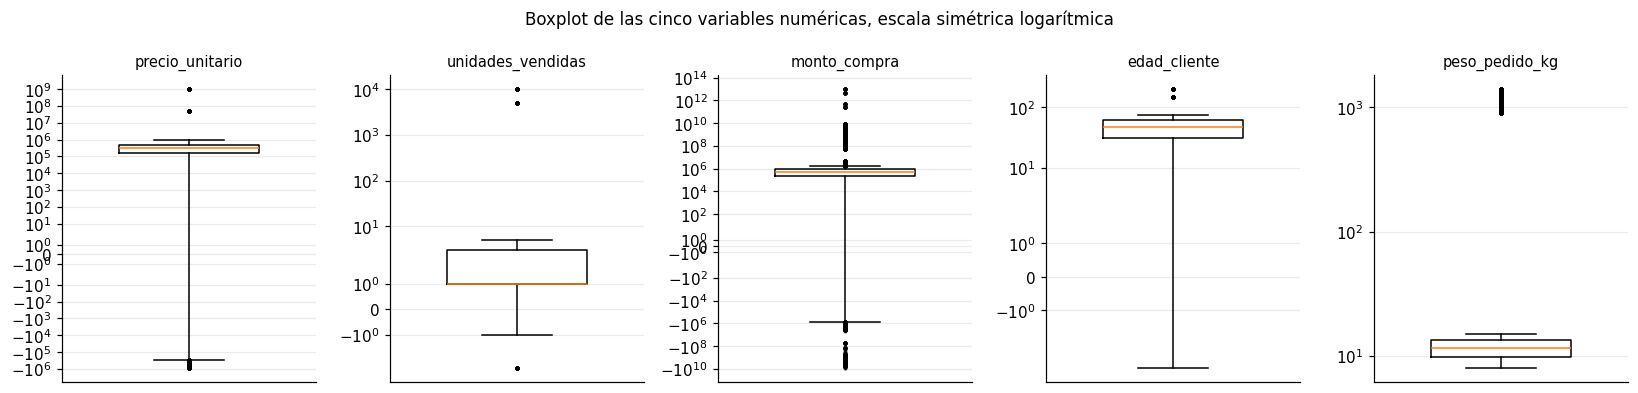

In [7]:
fig, ax = plt.subplots(1, 5, figsize=(15, 3.6))
for i, c in enumerate(NUMERICAS):
    ax[i].boxplot(df[c].dropna(), vert=True, widths=0.55,
                  flierprops=dict(marker=".", markersize=3, alpha=0.25))
    ax[i].set_title(c, fontsize=9.5)
    ax[i].set_yscale("symlog")
    ax[i].set_xticks([])
fig.suptitle("Boxplot de las cinco variables numéricas, escala simétrica logarítmica", fontsize=11)
fig.tight_layout()
plt.show()

La escala logarítmica es necesaria: en escala lineal el máximo de `monto_compra` aplasta la
caja hasta volverla una línea. Los puntos por debajo de cero en tres de las cinco variables ya
anticipan el diagnóstico.

## 1.6 · Confirmación visual con scatter plots

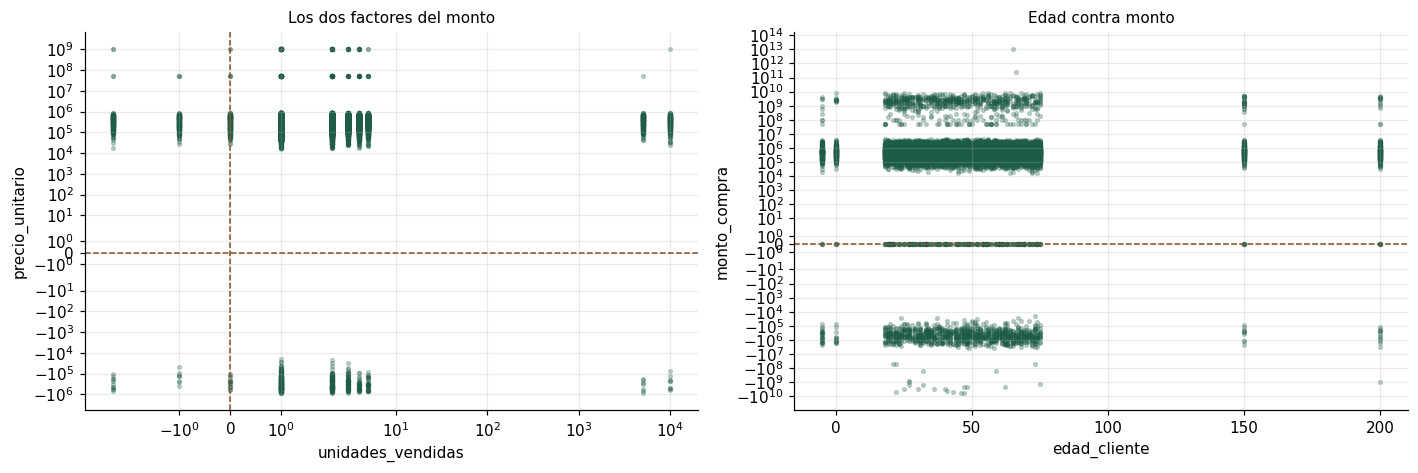

In [8]:
muestra = df.sample(n=min(20000, len(df)), random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

ax[0].scatter(muestra["unidades_vendidas"], muestra["precio_unitario"],
              s=6, alpha=0.25, color="#1D5C48")
ax[0].set_xscale("symlog"); ax[0].set_yscale("symlog")
ax[0].axhline(0, color="#8A4B2A", lw=1, ls="--")
ax[0].axvline(0, color="#8A4B2A", lw=1, ls="--")
ax[0].set_xlabel("unidades_vendidas"); ax[0].set_ylabel("precio_unitario")
ax[0].set_title("Los dos factores del monto", fontsize=10)

ax[1].scatter(muestra["edad_cliente"], muestra["monto_compra"],
              s=6, alpha=0.25, color="#1D5C48")
ax[1].set_yscale("symlog")
ax[1].axhline(0, color="#8A4B2A", lw=1, ls="--")
ax[1].set_xlabel("edad_cliente"); ax[1].set_ylabel("monto_compra")
ax[1].set_title("Edad contra monto", fontsize=10)

fig.tight_layout()
plt.show()

El primer gráfico muestra cuatro cuadrantes ocupados cuando solo el superior derecho es
posible: no existen unidades negativas ni precios negativos en una venta real. El segundo muestra
dos columnas verticales aisladas en los extremos del eje de edad, que son los valores imposibles.

---
# Parte 2 · Diagnóstico antes de decidir

Un valor extremo no es lo mismo que un error. Antes de aplicar ningún tratamiento se clasifica
cada grupo de atípicos según su origen.

## 2.1 · La regla de consistencia entre las tres variables monetarias

`monto_compra` no es una variable independiente: debería ser el producto de `precio_unitario` por
`unidades_vendidas`. Si la regla se cumple, los montos extremos no son errores de monto sino
consecuencias de los otros dos campos.

In [9]:
m = df["precio_unitario"].notna() & df["monto_compra"].notna()
esperado = df.loc[m, "precio_unitario"] * df.loc[m, "unidades_vendidas"]
diferencia = (df.loc[m, "monto_compra"] - esperado).abs()
cumple = diferencia <= 0.01

pd.DataFrame({"valor": [
    int(m.sum()), int(cumple.sum()), int((~cumple).sum()),
    round(100 * cumple.mean(), 2),
]}, index=["filas evaluables", "cumplen monto = precio × unidades",
           "no cumplen", "porcentaje que cumple"])

,valor
filas evaluables,599000.0
cumplen monto = precio × unidades,599000.0
no cumplen,0.0
porcentaje que cumple,100.0


**La regla se cumple en el 100 % de las filas evaluables.** Es el hallazgo que ordena todo el
tratamiento: los montos de hasta 9,99 billones no son errores de captura del monto, son el
resultado aritmético correcto de precios y unidades corruptos.

La consecuencia práctica es directa. Aplicar `clip()` sobre `monto_compra` produciría filas donde
el monto ya no cuadra con sus propios factores, y cualquier análisis posterior que recalcule el
monto obtendría un número distinto al almacenado. **Hay que tratar las causas, no el síntoma.**

## 2.2 · Detección sistemática de centinelas por análisis de saltos

Los sistemas antiguos codifican un dato faltante con una secuencia de nueves o con una cifra
redonda, en vez de dejarlo vacío. Buscarlos a ojo es poco fiable, así que se usa un criterio
objetivo: en una distribución continua real los valores consecutivos están cerca unos de otros,
mientras que un centinela queda separado del resto por un salto abrupto.

Se calcula la razón entre cada valor único y el anterior, y se miran los saltos más grandes.

In [10]:
def saltos_en_cola(s, top=3):
    u = np.sort(s.dropna().unique())
    u = u[u > 0]
    razon = u[1:] / np.maximum(u[:-1], 1e-9)
    idx = np.argsort(razon)[-top:][::-1]
    return [(u[i], u[i + 1], razon[i]) for i in idx]

for c in ["precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]:
    print(f"{c}")
    for desde, hasta, r in saltos_en_cola(df[c]):
        print(f"   de {desde:>15,.1f}  a {hasta:>15,.1f}   salto de x{r:,.1f}")
    print()

precio_unitario
   de       899,600.0  a    50,000,000.0   salto de x55.6
   de    50,000,000.0  a   999,000,000.0   salto de x20.0
   de        15,100.0  a        15,500.0   salto de x1.0

unidades_vendidas
   de             5.0  a         5,000.0   salto de x1,000.0
   de             1.0  a             2.0   salto de x2.0
   de         5,000.0  a         9,999.0   salto de x2.0

edad_cliente
   de            75.0  a           150.0   salto de x2.0
   de           150.0  a           200.0   salto de x1.3
   de            18.0  a            19.0   salto de x1.1

peso_pedido_kg
   de            15.0  a           900.0   salto de x60.0
   de             8.0  a             8.1   salto de x1.0
   de             8.1  a             8.2   salto de x1.0



Los saltos delatan **dos capas** de valores centinela, no una.

En `precio_unitario` hay un salto de x55,6 entre 899.600 y 50.000.000, y otro de x20,0 hasta
999.000.000. En `unidades_vendidas` el salto de 5 a 5.000 es de x1.000. En `edad_cliente` la
distribución real termina en 75 y luego aparecen 150 y 200, o sea **tres** valores imposibles y no
uno solo. Y `peso_pedido_kg` salta de 15 a 900, con x60.

Habría sido fácil quedarse solo con la capa más visible de cada variable. El análisis de saltos
obliga a mirar todas.

In [11]:
centinelas = {
    "unidades_vendidas": [9999, 5000],
    "edad_cliente":      [200, 150],
    "precio_unitario":   [999000000.0, 50000000.0],
}

filas = []
for c, valores in centinelas.items():
    for v in valores:
        s_c = df[c]
        anterior = s_c[(s_c < v) & (s_c > 0)].max()
        filas.append({
            "variable": c, "centinela": v,
            "repeticiones": int((s_c == v).sum()),
            "% del total": round(100 * (s_c == v).mean(), 2),
            "último valor real antes": anterior,
            "salto": round(v / anterior, 1) if anterior and anterior > 0 else None,
        })
pd.DataFrame(filas).set_index("variable")

,centinela,repeticiones,% del total,último valor real antes,salto
variable,,,,,
unidades_vendidas,9999.0,9068,1.46,5000.0,2.0
unidades_vendidas,5000.0,8889,1.43,5.0,1000.0
edad_cliente,200.0,9004,1.45,150.0,1.3
edad_cliente,150.0,8984,1.45,75.0,2.0
precio_unitario,999000000.0,2964,0.48,50000000.0,20.0
precio_unitario,50000000.0,3036,0.49,899600.0,55.6


**Diagnóstico: son errores, no datos.** Tres señales lo confirman en los cinco casos. El valor
se repite miles de veces de forma idéntica, cosa que no ocurre en una variable continua real. Son
cifras artificialmente redondas o de nueves. Y entre el centinela y el último valor observado no
hay absolutamente nada, cuando una cola real es continua.

A eso se suma el criterio de negocio: una edad de 200 años, un precio de 999 millones o de 50
millones por unidad, y 5.000 o 9.999 unidades en un pedido de retail cuando la mediana es 2, no
son situaciones posibles.

## 2.3 · Valores imposibles por el dominio del negocio

Independientemente de lo que digan el IQR o el z-score, hay valores que no pueden existir.

In [12]:
imposibles = pd.DataFrame({
    "regla": ["precio_unitario < 0", "unidades_vendidas < 0", "edad_cliente < 0",
              "edad_cliente = 0", "monto_compra < 0"],
    "filas": [
        int((df.precio_unitario < 0).sum()),
        int((df.unidades_vendidas < 0).sum()),
        int((df.edad_cliente < 0).sum()),
        int((df.edad_cliente == 0).sum()),
        int((df.monto_compra < 0).sum()),
    ],
})
imposibles["% del total"] = (100 * imposibles["filas"] / len(df)).round(2)
display(imposibles)

neg_m = df.monto_compra < 0
neg_causa = (df.unidades_vendidas < 0) | (df.precio_unitario < 0)
pd.DataFrame({"valor": [
    int(neg_m.sum()), int((neg_m & neg_causa).sum()),
    int((neg_m & ~neg_causa).sum()),
]}, index=["monto negativo", "explicado por precio o unidades negativos",
           "sin explicar"])

,regla,filas,% del total
0,precio_unitario < 0,19000,3.06
1,unidades_vendidas < 0,17974,2.90
2,edad_cliente < 0,8969,1.45
3,edad_cliente = 0,9043,1.46
4,monto_compra < 0,35031,5.65


,valor
monto negativo,35031
explicado por precio o unidades negativos,35031
sin explicar,0


Los 35.031 montos negativos quedan explicados en su totalidad por un precio o unas unidades
negativas. La cadena causal es consistente.

**Por qué no se interpretan las unidades negativas como devoluciones.** Sería la lectura natural
en retail, pero no se sostiene aquí: también hay 19.000 precios negativos, y una devolución no
tiene precio unitario negativo. Como ambos aparecen en volúmenes parecidos y el dataset no tiene
ninguna columna que distinga venta de devolución, la explicación más económica es un error
sistemático de captura del signo. Queda documentado como supuesto, no como certeza.

## 2.4 · Atípicos legítimos

No todo lo que sale del rango es un error. Se revisa la cola alta de las variables una vez
descontados los centinelas y los imposibles.

In [13]:
limpio_prov = df[
    (df.precio_unitario > 0) & (~df.precio_unitario.isin([999000000.0, 50000000.0])) &
    (df.unidades_vendidas > 0) & (~df.unidades_vendidas.isin([9999, 5000]))
]

filas = []
for c in ["precio_unitario", "unidades_vendidas", "monto_compra", "peso_pedido_kg"]:
    s_c = limpio_prov[c].dropna()
    filas.append({
        "variable": c, "n": len(s_c),
        "p50": round(s_c.quantile(0.50), 2), "p95": round(s_c.quantile(0.95), 2),
        "p99": round(s_c.quantile(0.99), 2), "max": round(s_c.max(), 2),
        "max/p99": round(s_c.max() / s_c.quantile(0.99), 1),
    })
pd.DataFrame(filas).set_index("variable")

,n,p50,p95,p99,max,max/p99
variable,,,,,,
precio_unitario,532308,312400.0,714000.0,817500.0,899600.0,1.1
unidades_vendidas,532308,2.0,4.0,5.0,5.0,1.0
monto_compra,532308,476400.0,1919100.0,2924400.0,4457500.0,1.5
peso_pedido_kg,532308,11.7,900.2,1297.1,1399.9,1.1


Descontadas **las dos capas** de centinelas y los valores imposibles, las colas se vuelven
razonables: el máximo queda apenas por encima del percentil 99 en las cuatro variables. Ese es el
comportamiento de una distribución asimétrica normal en retail, no el de un error.

La comparación con la corrida anterior es la prueba de que la segunda capa importaba. Retirando
solo la primera, el máximo de `precio_unitario` quedaba 59 veces por encima de su percentil 99 y
el del monto 219 veces. Retirando las dos, ambos bajan a menos de 1,6.

`peso_pedido_kg` es el caso más ambiguo y merece su propio análisis, que va a continuación.

### El caso de `peso_pedido_kg`: ni centinela ni cola legítima

No tiene negativos ni un valor único repetido, así que no encaja en ninguno de los dos grupos
anteriores. Pero el análisis de saltos mostró un x60 entre 15 y 900, y eso obliga a mirar la
distribución completa antes de decidir.

In [14]:
s_p = df["peso_pedido_kg"].dropna()

pd.DataFrame({"valor": [
    int((s_p <= 15).sum()),
    int(((s_p > 15) & (s_p < 900)).sum()),
    int((s_p >= 900).sum()),
    f"{s_p[s_p <= 15].min():,.1f} a {s_p[s_p <= 15].max():,.1f}",
    f"{s_p[s_p >= 900].min():,.1f} a {s_p[s_p >= 900].max():,.1f}",
    int(s_p[s_p >= 900].nunique()),
]}, index=["pedidos de 15 kg o menos", "pedidos entre 15 y 900 kg",
           "pedidos de 900 kg o más", "rango del bloque bajo",
           "rango del bloque alto", "valores distintos en el bloque alto"])

,valor
pedidos de 15 kg o menos,589000
pedidos entre 15 y 900 kg,0
pedidos de 900 kg o más,31000
rango del bloque bajo,8.0 a 15.0
rango del bloque alto,"900.0 a 1,399.9"
valores distintos en el bloque alto,4992


**No hay un solo pedido entre 15 y 900 kg.** El vacío es total, y eso descarta que se trate de
una cola continua: una distribución real de pesos tendría valores intermedios.

Tampoco es un centinela, porque el bloque alto contiene 4.992 valores distintos, o sea una
distribución completa y no una constante repetida.

**Diagnóstico: son dos poblaciones distintas mezcladas en una misma columna.** Las dos lecturas
posibles son un segundo canal de venta con otra escala, por ejemplo pedidos mayoristas o por
estiba, o un error de unidad en una parte de los registros. El dataset no tiene ninguna columna
que permita distinguirlas, así que **la ambigüedad se documenta en vez de resolverse por
suposición**.

Esa incertidumbre define el tratamiento: no se anula, porque podría ser información real, y no se
deja intacto, porque un bloque del 5 % a un orden de magnitud de distancia distorsiona cualquier
promedio. Se capa con `clip()` y se conserva el valor original en una columna aparte, que es la
opción reversible.

## 2.5 · Tabla de decisión

| Grupo | Origen | Evidencia | Tratamiento |
|---|---|---|---|
| Centinelas capa 1: 9999, 200 y 999.000.000 | Error de codificación de faltante | Valor único repetido miles de veces, patrón de nueves, salto abrupto contra el siguiente valor | Convertir a nulo y marcar con bandera |
| Centinelas capa 2: 5.000 y 50.000.000 | Error de codificación de faltante | Detectados por análisis de saltos: x1.000 y x55,6 contra el último valor real | Convertir a nulo y marcar con bandera |
| Precio, unidades y edad negativos | Error de captura del signo | Imposible en el dominio, y los precios negativos descartan la hipótesis de devolución | Convertir a nulo y marcar con bandera |
| Edad igual a cero, 150 y 200 | Error o faltante codificado con un número | La distribución real termina en 75, y un cliente no tiene cero años | Convertir a nulo y marcar con bandera |
| `monto_compra` extremo | Consecuencia aritmética, no error propio | La regla monto = precio × unidades se cumple al 100 % | No se toca directamente: se recalcula desde los factores ya limpios |
| Bloque alto de `peso_pedido_kg` | Ambiguo: segundo canal de venta o error de unidad | Vacío total entre 15 y 900 kg, pero 4.992 valores distintos en el bloque alto, así que no es centinela | Capar al percentil 99 con `clip()` y conservar el original, por ser la opción reversible ante la ambigüedad |

**Por qué no se elimina ninguna fila.** Un pedido con la edad del cliente corrupta conserva
válidos la fecha, la ciudad, el canal, el método de pago y la categoría. Borrar la fila destruiría
esa información para corregir un solo campo. Anular el valor y dejar una bandera preserva todo lo
demás y permite que cualquier análisis posterior decida si excluye o imputa.

---
# Parte 3 · Tratamiento

## 3.1 · Centinelas y valores imposibles

In [15]:
lim = df.copy()

REGLAS = {
    "precio_unitario":   lambda s: (s < 0) | s.isin([999000000.0, 50000000.0]),
    "unidades_vendidas": lambda s: (s < 0) | s.isin([9999, 5000]),
    "edad_cliente":      lambda s: (s < 0) | s.isin([200, 150]) | (s == 0),
}

resumen = []
for col, regla in REGLAS.items():
    marca = regla(lim[col]).fillna(False)
    lim[col + "_atipico"] = marca
    lim.loc[marca, col] = np.nan
    resumen.append({"variable": col, "valores anulados": int(marca.sum()),
                    "% del total": round(100 * marca.mean(), 2)})

pd.DataFrame(resumen).set_index("variable")

,valores anulados,% del total
variable,,
precio_unitario,25000,4.03
unidades_vendidas,35931,5.80
edad_cliente,36000,5.81


## 3.2 · Recálculo de `monto_compra` desde los factores limpios

Como la regla de consistencia se cumplía al 100 %, el monto se reconstruye en lugar de recortarse.
Donde alguno de los dos factores quedó nulo, el monto también queda nulo y se marca.

In [16]:
monto_previo = lim["monto_compra"].copy()

lim["monto_compra"] = lim["precio_unitario"] * lim["unidades_vendidas"]
lim["monto_atipico"] = lim["monto_compra"].isna() & monto_previo.notna()

pd.DataFrame({"valor": [
    round(monto_previo.min(), 2), round(monto_previo.max(), 2),
    round(lim["monto_compra"].min(), 2), round(lim["monto_compra"].max(), 2),
    int(lim["monto_atipico"].sum()),
    int((lim["monto_compra"] < 0).sum()),
]}, index=["mínimo antes", "máximo antes", "mínimo después", "máximo después",
           "montos anulados por arrastre", "montos negativos restantes"])

,valor
mínimo antes,-8.580142e+09
máximo antes,9.989001e+12
mínimo después,0.000000e+00
máximo después,4.457500e+06
montos anulados por arrastre,5.829100e+04
montos negativos restantes,0.000000e+00


El máximo baja de 9,99 billones a un valor del orden del negocio real, y no queda ningún monto
negativo. Nada de esto requirió tocar `monto_compra` directamente: se corrigió el origen.

## 3.3 · Capado del bloque alto con `clip()`

`peso_pedido_kg` quedó diagnosticado como ambiguo, así que se elige el tratamiento reversible: se
capa al percentil 99 para limitar la influencia del bloque alto sobre los promedios, y el valor
original se conserva íntegro en `peso_pedido_kg_original`. Si más adelante aparece la columna que
distinga los dos canales, la decisión se puede deshacer sin haber perdido nada.

In [17]:
p99_peso = lim["peso_pedido_kg"].quantile(0.99)

lim["peso_pedido_kg_original"] = lim["peso_pedido_kg"]
lim["peso_pedido_kg"] = lim["peso_pedido_kg"].clip(upper=p99_peso)
lim["peso_capado"] = lim["peso_pedido_kg_original"] > p99_peso

pd.DataFrame({
    "antes": [round(lim.peso_pedido_kg_original.max(), 2),
              round(lim.peso_pedido_kg_original.mean(), 2),
              round(lim.peso_pedido_kg_original.std(), 2)],
    "después": [round(lim.peso_pedido_kg.max(), 2),
                round(lim.peso_pedido_kg.mean(), 2),
                round(lim.peso_pedido_kg.std(), 2)],
}, index=["máximo", "media", "desviación estándar"]).assign(
    **{"valores capados": [int(lim.peso_capado.sum()), "", ""]})

,antes,después,valores capados
máximo,1399.90,1298.20,6197
media,68.39,67.88,
desviación estándar,250.06,247.46,


## 3.4 · Verificación posterior al tratamiento

In [18]:
filas = []
for c in NUMERICAS:
    a, d = df[c].dropna(), lim[c].dropna()
    _, _, _, lia, lsa = limites_iqr(a)
    _, _, _, lid, lsd = limites_iqr(d)
    filas.append({
        "variable": c,
        "max antes": round(a.max(), 2), "max después": round(d.max(), 2),
        "min antes": round(a.min(), 2), "min después": round(d.min(), 2),
        "atíp. IQR antes": int(((a < lia) | (a > lsa)).sum()),
        "atíp. IQR después": int(((d < lid) | (d > lsd)).sum()),
        "asim. antes": round(a.skew(), 2), "asim. después": round(d.skew(), 2),
    })
pd.DataFrame(filas).set_index("variable")

,max antes,max después,min antes,min después,atíp. IQR antes,atíp. IQR después,asim. antes,asim. después
variable,,,,,,,,
precio_unitario,9.990000e+08,899600.0,-8.881000e+05,15100.0,15844,0,14.06,0.54
unidades_vendidas,9.999000e+03,5.0,-3.000000e+00,0.0,26870,68948,6.46,1.13
monto_compra,9.989001e+12,4457500.0,-8.580142e+09,0.0,64816,37552,92.05,2.00
edad_cliente,2.000000e+02,75.0,-5.000000e+00,18.0,17988,0,2.50,-0.00
peso_pedido_kg,1.399900e+03,1298.2,8.000000e+00,8.0,31000,31000,4.24,4.22


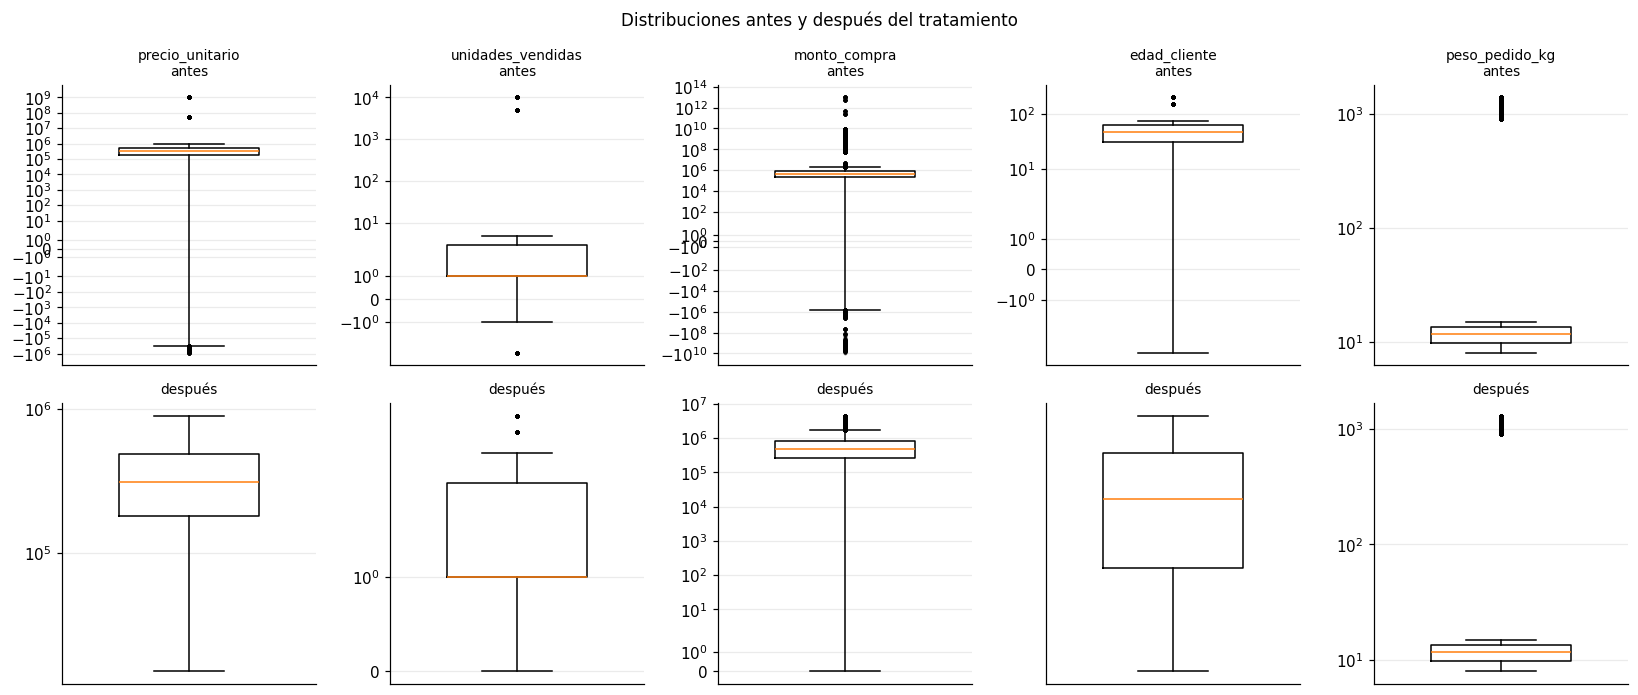

In [19]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6.4))
for i, c in enumerate(NUMERICAS):
    ax[0, i].boxplot(df[c].dropna(), widths=0.55,
                     flierprops=dict(marker=".", markersize=3, alpha=0.25))
    ax[0, i].set_title(f"{c}\nantes", fontsize=9)
    ax[0, i].set_yscale("symlog"); ax[0, i].set_xticks([])
    ax[1, i].boxplot(lim[c].dropna(), widths=0.55,
                     flierprops=dict(marker=".", markersize=3, alpha=0.25))
    ax[1, i].set_title("después", fontsize=9)
    ax[1, i].set_yscale("symlog"); ax[1, i].set_xticks([])
fig.suptitle("Distribuciones antes y después del tratamiento", fontsize=11)
fig.tight_layout()
plt.show()

Las cajas dejan de estar aplastadas contra el cero y desaparecen los puntos por debajo de la
línea. La asimetría de `monto_compra` cae de 92 a un valor propio de una distribución de ventas.

---
# Parte 4 · Ruido y suavizado de la serie diaria

## 4.1 · Construcción de la serie

In [20]:
lim["fecha_pedido"] = pd.to_datetime(lim["fecha_pedido"], errors="coerce")

serie = (lim.dropna(subset=["fecha_pedido"])
            .groupby(lim["fecha_pedido"].dt.date)["monto_compra"]
            .sum()
            .rename("venta_diaria"))
serie.index = pd.to_datetime(serie.index)
serie = serie.sort_index()

pd.DataFrame({"valor": [len(serie), str(serie.index.min().date()),
                        str(serie.index.max().date()),
                        round(serie.mean(), 2), round(serie.std(), 2)]},
             index=["días con datos", "primer día", "último día",
                    "venta diaria media", "desviación estándar"])

,valor
días con datos,836
primer día,2025-01-01
último día,2027-12-28
venta diaria media,406861059.69
desviación estándar,312359958.49


## 4.2 · Media móvil de 7 y 30 días

La ventana de 7 días es la habitual en retail porque promedia una semana completa y por tanto
neutraliza el ciclo semanal. La de 30 días deja solo el movimiento de fondo.

In [21]:
suave = pd.DataFrame({"original": serie})
suave["mm_7"] = serie.rolling(window=7, center=True).mean()
suave["mm_30"] = serie.rolling(window=30, center=True).mean()

pd.DataFrame({
    "desviación estándar": [round(suave["original"].std(), 2),
                            round(suave["mm_7"].std(), 2),
                            round(suave["mm_30"].std(), 2)],
    "% de ruido eliminado": [0.0,
        round(100 * (1 - suave["mm_7"].std() / suave["original"].std()), 1),
        round(100 * (1 - suave["mm_30"].std() / suave["original"].std()), 1)],
}, index=["serie original", "media móvil 7 días", "media móvil 30 días"])

,desviación estándar,% de ruido eliminado
serie original,3.123600e+08,0.0
media móvil 7 días,3.107251e+08,0.5
media móvil 30 días,3.070284e+08,1.7


## 4.3 · Comparación gráfica antes y después

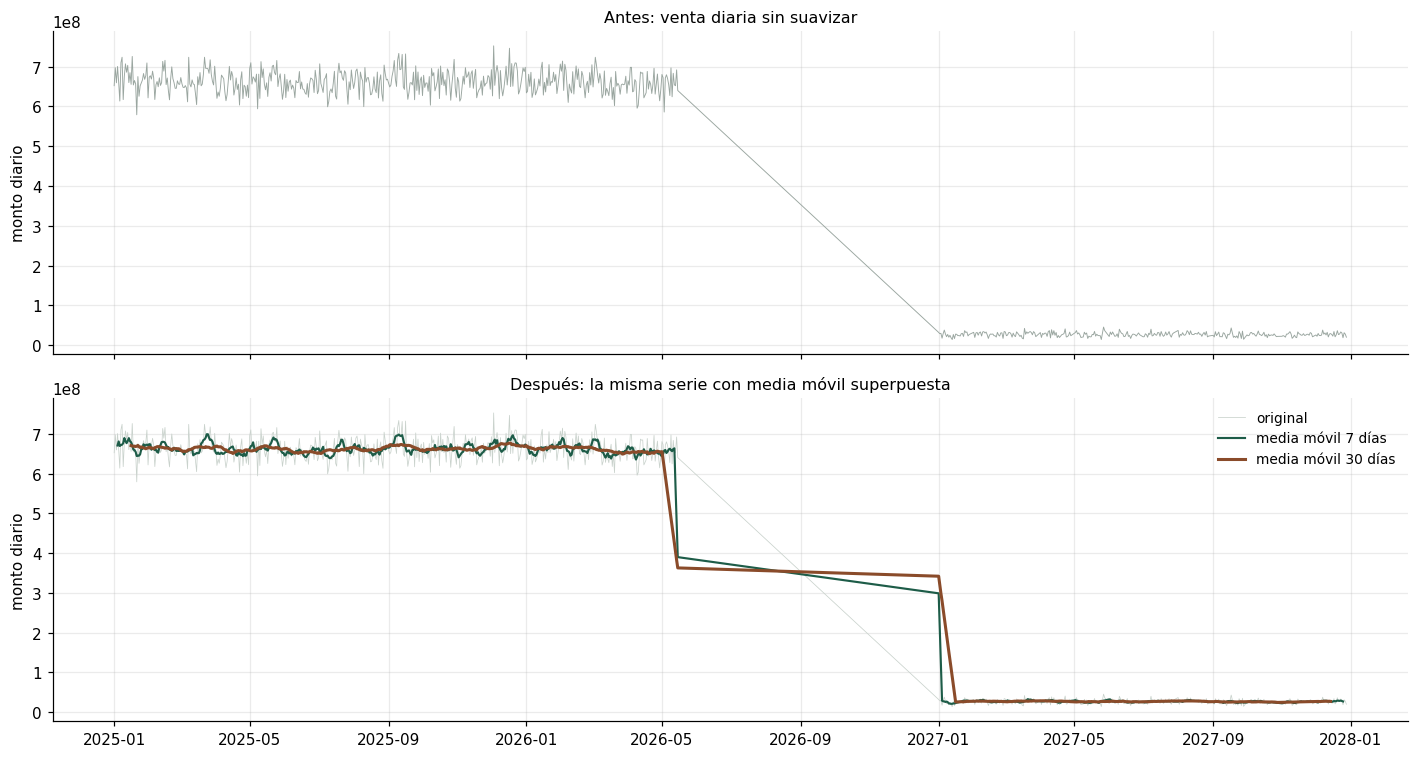

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax[0].plot(suave.index, suave["original"], lw=0.6, color="#9AA6A0")
ax[0].set_title("Antes: venta diaria sin suavizar", fontsize=10.5)
ax[0].set_ylabel("monto diario")

ax[1].plot(suave.index, suave["original"], lw=0.5, color="#C9D2CC", label="original")
ax[1].plot(suave.index, suave["mm_7"], lw=1.4, color="#1D5C48", label="media móvil 7 días")
ax[1].plot(suave.index, suave["mm_30"], lw=2.0, color="#8A4B2A", label="media móvil 30 días")
ax[1].set_title("Después: la misma serie con media móvil superpuesta", fontsize=10.5)
ax[1].set_ylabel("monto diario")
ax[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

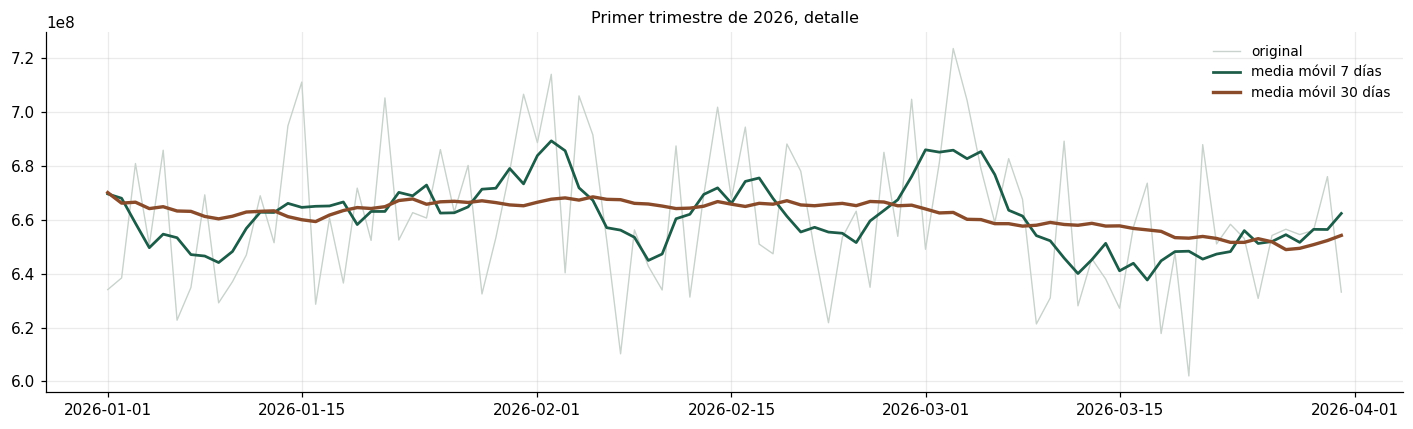

In [23]:
# Acercamiento a un trimestre para ver el detalle que el panorama completo esconde
ventana = suave.loc["2026-01-01":"2026-03-31"]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ventana.index, ventana["original"], lw=0.9, color="#C9D2CC", label="original")
ax.plot(ventana.index, ventana["mm_7"], lw=1.8, color="#1D5C48", label="media móvil 7 días")
ax.plot(ventana.index, ventana["mm_30"], lw=2.2, color="#8A4B2A", label="media móvil 30 días")
ax.set_title("Primer trimestre de 2026, detalle", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 4.4 · Qué se ve ahora que antes no se veía

El resultado no es el que se esperaría de una serie de ventas real, y esa es justamente la
conclusión.

La media móvil de 7 días reduce la desviación estándar apenas un 0,5 %, y la de 30 días un 1,7 %.
En una serie de retail auténtica la ventana de 7 días suele recortar buena parte de la varianza,
porque el ciclo semanal es la componente dominante. Aquí casi no recorta nada.

**Lo que el suavizado revela es que no hay ciclo semanal ni tendencia.** Las curvas suavizadas
salen prácticamente planas y horizontales, sin subidas de fin de año ni caídas de temporada baja.
La tabla siguiente lo confirma: ningún día de la semana se aparta más de 0,8 % del promedio,
cuando en un comercio real el sábado y el domingo se separan del resto en dos dígitos.

Antes del suavizado esto no se podía afirmar: la serie diaria oscilaba lo suficiente como para que
uno creyera estar viendo estacionalidad. Al promediar, la oscilación desaparece y queda a la vista
que era ruido aleatorio alrededor de un nivel constante.

**Consecuencia para el uso del dataset.** Cualquier modelo de pronóstico que se entrene sobre esta
serie no va a encontrar estacionalidad que capturar, y un baseline ingenuo será difícil de superar.
Conviene documentarlo antes de que alguien invierta tiempo buscando patrones temporales que el
dato no contiene.

In [24]:
# Evidencia numérica: cuánto se aparta cada día de la semana del promedio general
por_dia = serie.groupby(serie.index.dayofweek).mean()
por_dia.index = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

resultado = por_dia.round(0).to_frame("venta media")
resultado["% contra el promedio"] = (100 * (por_dia / serie.mean() - 1)).round(2)
display(resultado)

pd.DataFrame({"valor": [
    round(abs(100 * (por_dia / serie.mean() - 1)).max(), 2),
    "no se detecta ciclo semanal",
]}, index=["desviación máxima entre días, en %", "lectura"])

,venta media,% contra el promedio
lunes,407645024.0,0.19
martes,406450831.0,-0.10
miércoles,407418428.0,0.14
jueves,406816168.0,-0.01
viernes,406845691.0,-0.00
sábado,409224507.0,0.58
domingo,403622592.0,-0.80


,valor
"desviación máxima entre días, en %",0.8
lectura,no se detecta ciclo semanal


---
# Parte 5 · Exportación y resumen

In [25]:
banderas = [c for c in lim.columns if c.endswith("_atipico") or c == "peso_capado"]

resumen_final = pd.DataFrame({"valor": [
    filas_inicio, len(lim), lim.shape[1],
    int(lim[banderas].any(axis=1).sum()),
    round(100 * lim[banderas].any(axis=1).mean(), 2),
    int((lim["monto_compra"] < 0).sum()),
    round(lim["monto_compra"].max(), 2),
]}, index=["filas de entrada", "filas de salida", "columnas de salida",
           "filas con al menos un valor tratado", "porcentaje de filas afectadas",
           "montos negativos restantes", "monto máximo final"])
display(resumen_final)

lim[banderas].sum().to_frame("valores marcados")

,valor
filas de entrada,620000.00
filas de salida,620000.00
columnas de salida,34.00
filas con al menos un valor tratado,97251.00
porcentaje de filas afectadas,15.69
montos negativos restantes,0.00
monto máximo final,4457500.00


,valores marcados
precio_unitario_atipico,25000
unidades_vendidas_atipico,35931
edad_cliente_atipico,36000
monto_atipico,58291
peso_capado,6197


In [26]:
lim.to_csv(SALIDA, index=False)

pd.DataFrame({"valor": [SALIDA, f"{os.path.getsize(SALIDA)/1048576:.1f} MB", len(lim)]},
             index=["archivo", "tamaño", "filas"])

,valor
archivo,S07_PD_Borja_DatasetSinOutliers.csv
tamaño,162.9 MB
filas,620000


**Ninguna fila se eliminó.** Se anularon valores puntuales y cada anulación quedó registrada en
una bandera, de modo que quien use este dataset después puede reconstruir exactamente qué se tocó
y decidir por su cuenta si excluye esas filas o imputa los valores.